<a href="https://colab.research.google.com/github/zainab590/Understand-Remote-Work-Burnout-A-Comparative-study-of-regression-and-Clustering-Technique.-/blob/main/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("sonalshinde123/work-from-home-employee-burnout-dataset")
print("Dataset path:", path)

import os
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'work-from-home-employee-burnout-dataset' dataset.
Dataset path: /kaggle/input/work-from-home-employee-burnout-dataset
Shape: (1800, 11)


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


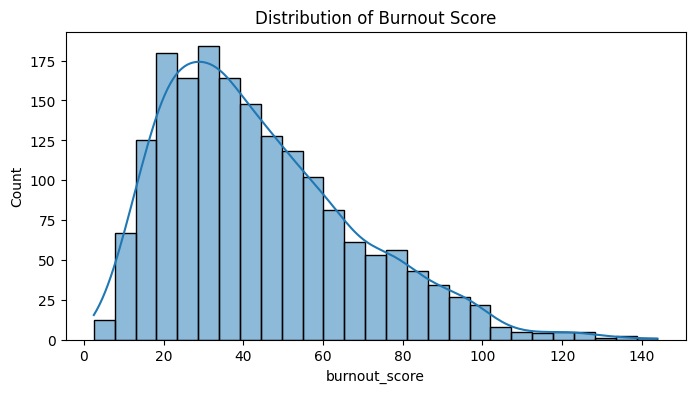

In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()   # all columns have 1800 non-null, so no missing values

# Target distribution
plt.figure(figsize=(8,4))
sns.histplot(df['burnout_score'], kde=True)
plt.title('Distribution of Burnout Score')
plt.show()

In [ ]:
# Drop identifier column
df = df.drop('user_id', axis=1)

# For regression, target is burnout_score; burnout_risk will be excluded (or used later for classification)
X = df.drop(['burnout_score', 'burnout_risk'], axis=1)
y = df['burnout_score']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1800, 8)
Target shape: (1800,)


In [ ]:
# Identify categorical columns (day_type is the only remaining categorical)
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Label encode day_type
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Now all features are numeric
X.head()

Categorical columns: ['day_type']


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,0,9.59,11.86,4,2,0,7.55,91.2
1,1,7.38,10.33,4,1,0,6.69,82.0
2,1,6.31,8.92,1,2,0,8.87,80.6
3,0,8.34,10.70,4,1,1,8.13,70.0
4,1,6.97,9.83,1,2,0,5.85,67.1


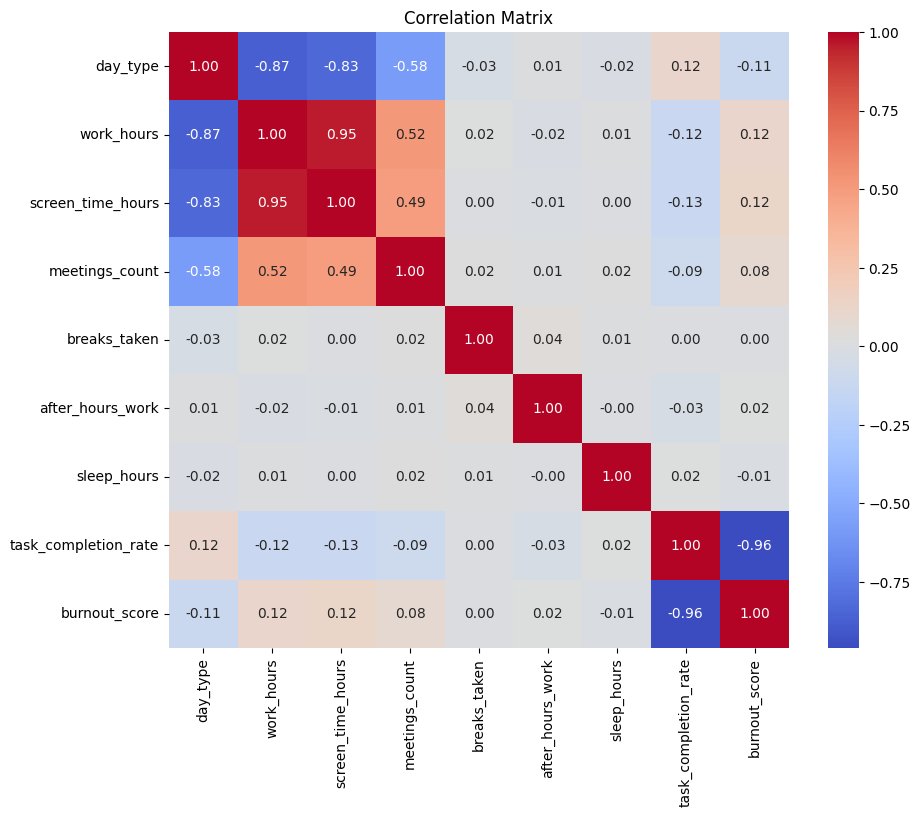

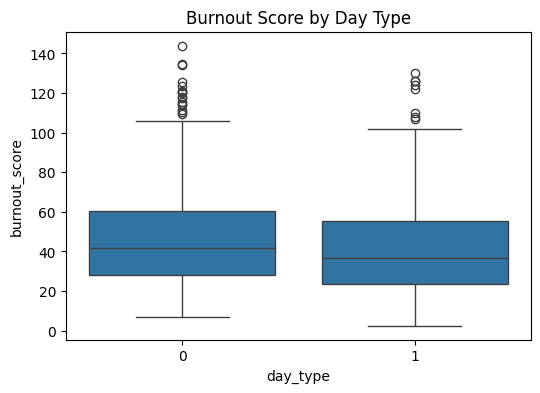

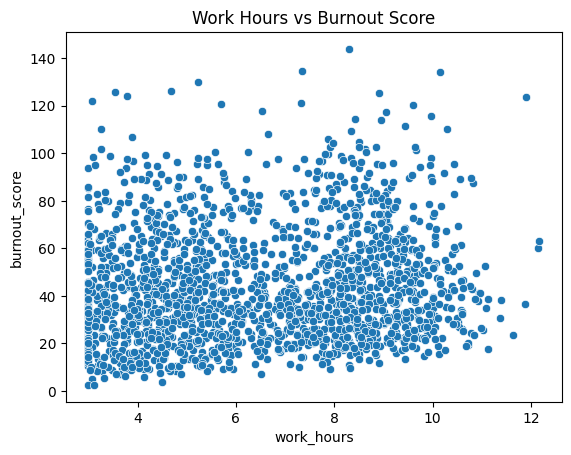

In [ ]:
# Correlation heatmap (including target)
full_data = X.copy()
full_data['burnout_score'] = y
plt.figure(figsize=(10,8))
sns.heatmap(full_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Boxplots for day_type vs burnout_score
plt.figure(figsize=(6,4))
sns.boxplot(x='day_type', y='burnout_score', data=pd.concat([X, y], axis=1))
plt.title('Burnout Score by Day Type')
plt.show()

# You can also explore other features vs target
sns.scatterplot(x='work_hours', y='burnout_score', data=full_data)
plt.title('Work Hours vs Burnout Score')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 1440, Test size: 360


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep unscaled versions for tree models
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_unscaled, y_train)
        y_pred = model.predict(X_test_unscaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

Linear Regression -> MAE: 4.8002, RMSE: 6.1341, R2: 0.9333
Random Forest -> MAE: 4.8062, RMSE: 6.1003, R2: 0.9340
XGBoost -> MAE: 4.8584, RMSE: 6.2356, R2: 0.9311


                        MAE      RMSE        R2
Linear Regression  4.800197  6.134106  0.933301
Random Forest      4.806240  6.100293  0.934035
XGBoost            4.858370  6.235618  0.931076


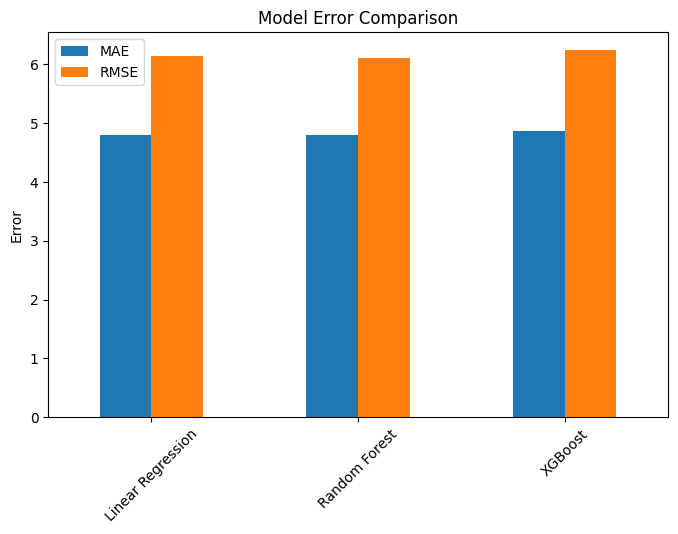

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title('Model Error Comparison')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.show()

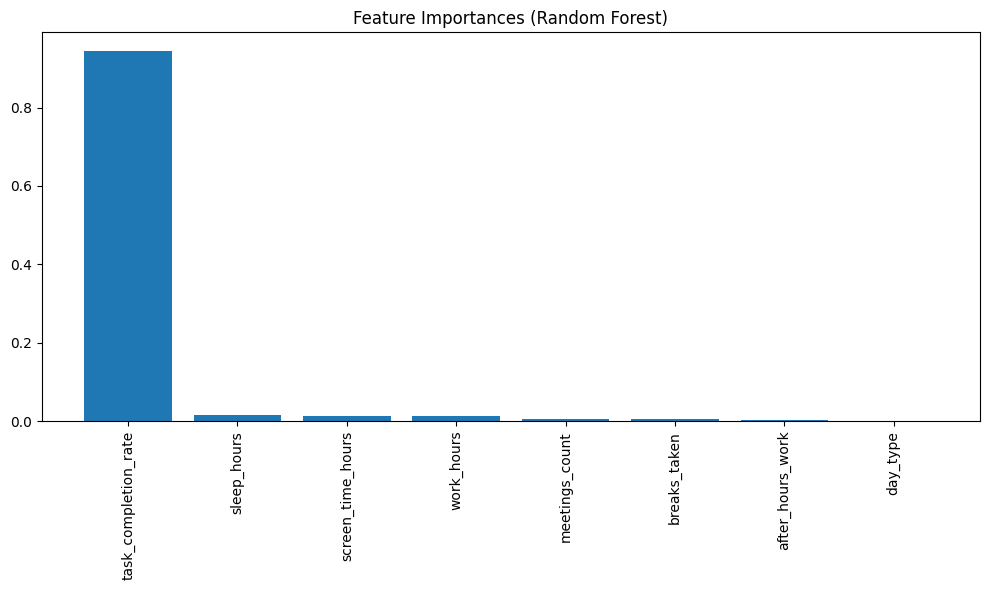

In [ ]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_unscaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_unscaled)
print("Test R2 with tuned model:", r2_score(y_test, y_pred_best))

Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV R2: 0.9207322628594721
Test R2 with tuned model: 0.9364077205981388


In [ ]:
import joblib
joblib.dump(best_rf, 'best_burnout_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Model and preprocessors saved.")

Model and preprocessors saved.


In [ ]:
# Example new data point (must have same columns as X)
new_data = pd.DataFrame([{
    'day_type': 'Weekday',
    'work_hours': 8.5,
    'screen_time_hours': 7.0,
    'meetings_count': 3,
    'breaks_taken': 2,
    'after_hours_work': 1,
    'sleep_hours': 6.5,
    'task_completion_rate': 0.85
}])

# Encode day_type using the saved encoder
new_data['day_type'] = label_encoders['day_type'].transform(new_data['day_type'])

# Scale (if using linear model) but for RF we can use unscaled
# For consistency, we'll use the same scaler (though RF doesn't need it)
new_data_scaled = scaler.transform(new_data)

prediction = best_rf.predict(new_data_scaled)  # or new_data if model was trained unscaled
print("Predicted burnout score:", prediction[0])

Predicted burnout score: 112.50789862919542


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported.")

Libraries imported.


In [ ]:
# Assuming dataset is already downloaded (use your path)
import kagglehub
path = kagglehub.dataset_download("sonalshinde123/work-from-home-employee-burnout-dataset")
import os
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'work-from-home-employee-burnout-dataset' dataset.
Shape: (1800, 11)


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [ ]:
# Drop user_id (identifier) and burnout-related columns from features
features = df.drop(['user_id', 'burnout_score', 'burnout_risk'], axis=1)

# Encode day_type
le = LabelEncoder()
features['day_type'] = le.fit_transform(features['day_type'])

print("Features for clustering:")
print(features.columns.tolist())
features.head()

Features for clustering:
['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,0,9.59,11.86,4,2,0,7.55,91.2
1,1,7.38,10.33,4,1,0,6.69,82.0
2,1,6.31,8.92,1,2,0,8.87,80.6
3,0,8.34,10.70,4,1,1,8.13,70.0
4,1,6.97,9.83,1,2,0,5.85,67.1


In [ ]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert back to DataFrame for convenience (optional)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled_df.head()

,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,-1.027032,1.342811,1.074737,1.214178,-0.725873,-0.748193,0.521490,1.261576
1,0.973680,0.377697,0.439509,1.214178,-1.431365,-0.748193,-0.288726,0.647197
2,0.973680,-0.089575,-0.145897,-0.554996,-0.725873,-0.748193,1.765077,0.553705
3,-1.027032,0.796932,0.593126,1.214178,-1.431365,1.336554,1.067915,-0.154166
4,0.973680,0.198649,0.231918,-0.554996,-0.725873,-0.748193,-1.080099,-0.347829


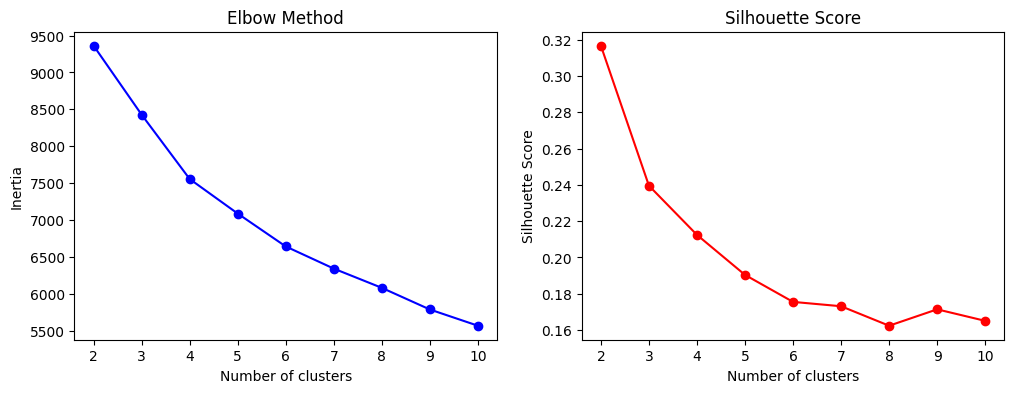

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [ ]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print("Cluster distribution:")
print(df['Cluster'].value_counts())

Cluster distribution:
Cluster
1    873
0    588
2    339
Name: count, dtype: int64


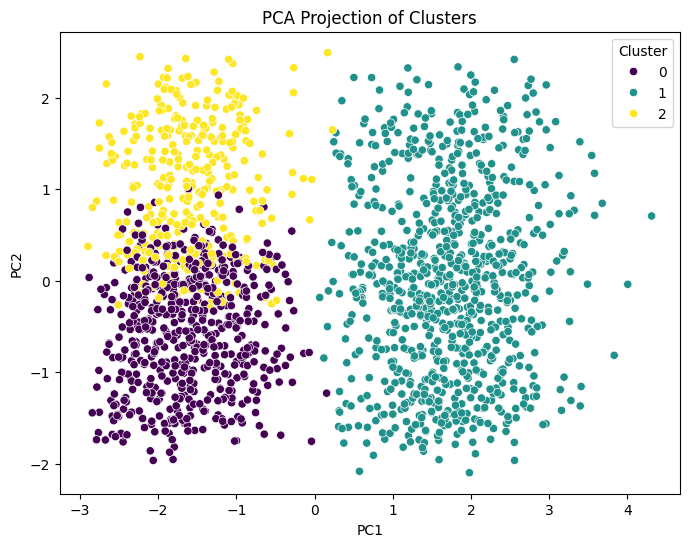

In [ ]:
pca = PCA(n_components=2, random_state=42)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=features_pca[:,0], y=features_pca[:,1], hue=cluster_labels, palette='viridis')
plt.title('PCA Projection of Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

Cluster Profiles (mean values):
         day_type  work_hours  screen_time_hours  meetings_count  \
Cluster                                                            
0        0.998299    4.578384           7.314796        0.957483   
1        0.001145    8.570080          11.343517        2.957617   
2        0.991150    4.582419           7.329027        1.029499   

         breaks_taken  after_hours_work  sleep_hours  task_completion_rate  
Cluster                                                                     
0            2.967687          0.000000     7.003384             74.493027  
1            3.067583          0.351661     7.012050             70.527377  
2            3.035398          1.000000     6.944336             73.106490  


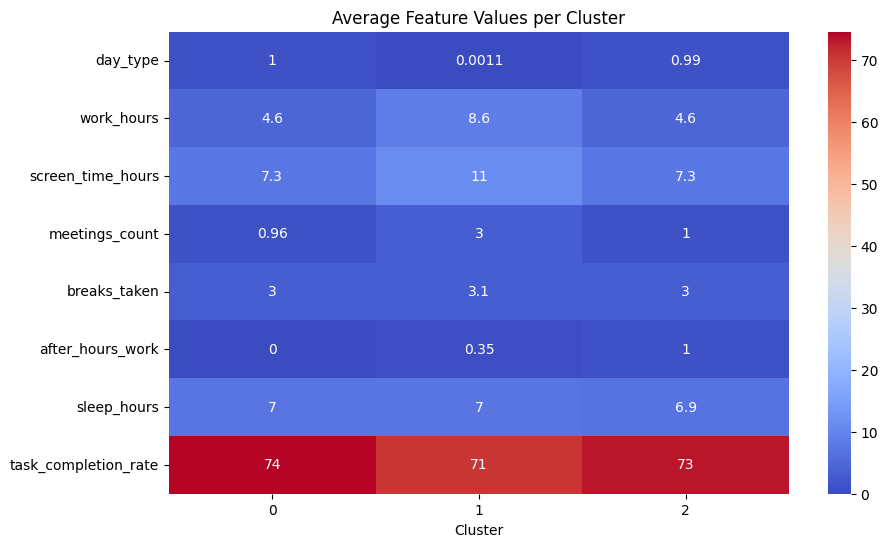

In [ ]:
# Add cluster to features (original scale) for interpretability
features_with_cluster = features.copy()
features_with_cluster['Cluster'] = cluster_labels

# Compute mean of each feature by cluster
cluster_profile = features_with_cluster.groupby('Cluster').mean()
print("Cluster Profiles (mean values):")
print(cluster_profile)

# Visualize as heatmap
plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile.T, annot=True, cmap='coolwarm')
plt.title('Average Feature Values per Cluster')
plt.show()

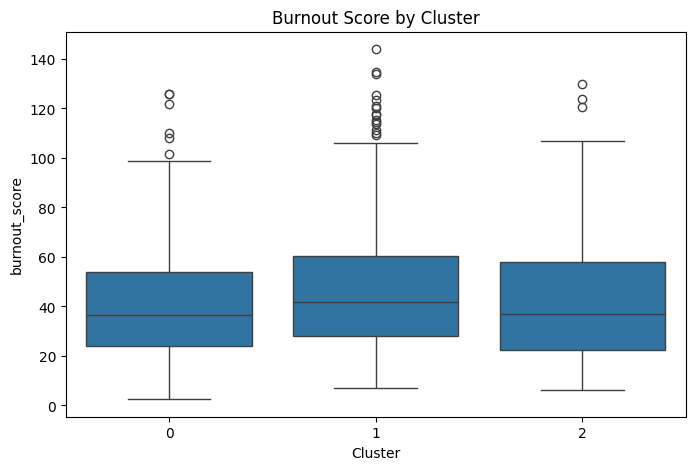

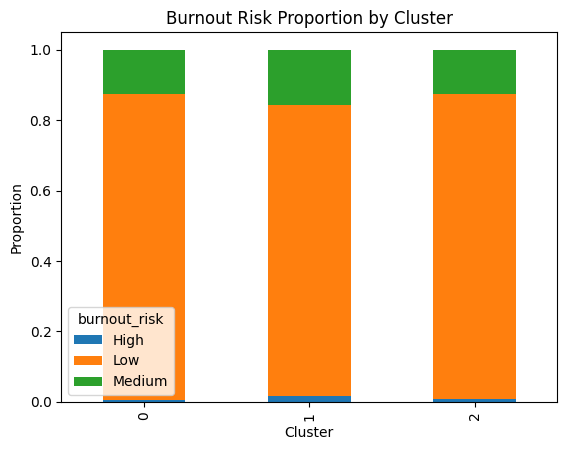

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='burnout_score', data=df)
plt.title('Burnout Score by Cluster')
plt.show()

# Also check burnout_risk distribution
pd.crosstab(df['Cluster'], df['burnout_risk'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Burnout Risk Proportion by Cluster')
plt.ylabel('Proportion')
plt.show()

In [ ]:
# Print cluster profiles again for reference
print("Cluster Profiles (mean values):")
print(cluster_profile)

# Map each cluster to a descriptive label based on its characteristics
# (You'll need to adjust the conditions based on your actual cluster means)
cluster_labels = {}
for cluster in cluster_profile.index:
    row = cluster_profile.loc[cluster]
    if row['work_hours'] > 8 and row['breaks_taken'] < 3:
        desc = "High workload, few breaks → high burnout risk"
    elif row['sleep_hours'] > 7 and row['screen_time_hours'] < 6:
        desc = "Good sleep, low screen time → low burnout"
    else:
        desc = "Moderate conditions → medium burnout"
    cluster_labels[cluster] = desc

print("\nInterpretation:")
for cluster, desc in cluster_labels.items():
    print(f"Cluster {cluster}: {desc}")

# Also show burnout statistics per cluster
print("\nBurnout Score by Cluster:")
print(df.groupby('Cluster')['burnout_score'].agg(['mean', 'std']))

Cluster Profiles (mean values):
         day_type  work_hours  screen_time_hours  meetings_count  \
Cluster                                                            
0        0.998299    4.578384           7.314796        0.957483   
1        0.001145    8.570080          11.343517        2.957617   
2        0.991150    4.582419           7.329027        1.029499   

         breaks_taken  after_hours_work  sleep_hours  task_completion_rate  
Cluster                                                                     
0            2.967687          0.000000     7.003384             74.493027  
1            3.067583          0.351661     7.012050             70.527377  
2            3.035398          1.000000     6.944336             73.106490  

Interpretation:
Cluster 0: Moderate conditions → medium burnout
Cluster 1: Moderate conditions → medium burnout
Cluster 2: Moderate conditions → medium burnout

Burnout Score by Cluster:
              mean        std
Cluster                 